In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score,
                            recall_score, f1_score,
                            classification_report,
                            confusion_matrix, ConfusionMatrixDisplay  
                            )

In [101]:
df = pd.read_csv("../data/processed/cleaned_sentiment140.csv")

In [102]:
df.head()

,Label,Serial,Date,Twitter_id,Clean_Text,Tokens
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,scotthamilton,is upset that he cannot update his facebook by...,"['upset', 'he', 'can', 'not', 'update', 'his',..."
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,mattycus,i dived many times for the ball. managed to sa...,"['i', 'dived', 'many', 'times', 'ball', '.', '..."
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,ElleCTF,my whole body feels itchy and like its on fire,"['my', 'whole', 'body', 'feels', 'itchy', 'lik..."
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,Karoli,"no, it is not behaving at all. i am mad. why a...","['no', ',', 'not', 'behaving', 'all', '.', 'i'..."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,joy_wolf,not the whole crew,"['not', 'whole', 'crew']"


In [103]:
X = df["Clean_Text"].fillna("").astype(str)
y = df["Label"]

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

In [105]:
X_train.shape

(1279999,)

In [106]:
X_test.shape

(320000,)

In [107]:
vectorize = CountVectorizer(max_features=10000)

### Vectorizing Text

In [108]:
X_train_vec = vectorize.fit_transform(X_train)
X_test_vec = vectorize.transform(X_test)

In [109]:
X_train_vec.shape

(1279999, 10000)

### First Model

In [110]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [111]:
y_pred = model.predict(X_test_vec)

In [112]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Precision: {precision:.2f}")

recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Recall: {recall:.2f}")

error_rate = 1 - accuracy
print(f"Error Rate:{error_rate:.2f}")

f1 = f1_score(y_test,y_pred, average="macro")
print(f"F1 Score: {f1:.2f}")


Accuracy: 0.80
Precision: 0.80
Recall: 0.80
Error Rate:0.20
F1 Score: 0.80


In [113]:
report = classification_report(y_test, y_pred)
print(f"Classification Report: {report}")

Classification Report:               precision    recall  f1-score   support

           0       0.81      0.78      0.79    160000
           1       0.78      0.82      0.80    160000

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



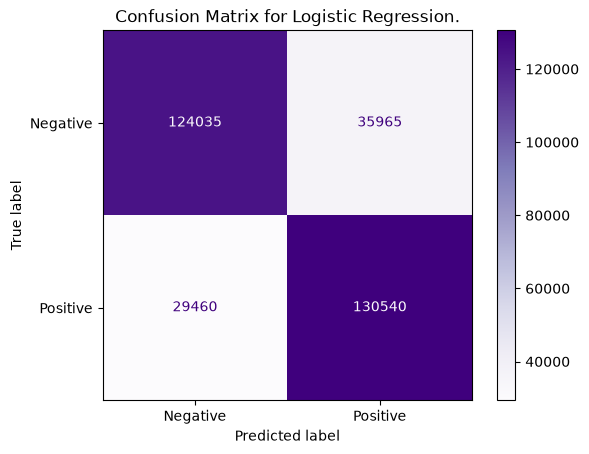

In [114]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Purples")
plt.title("Confusion Matrix for Logistic Regression.")
plt.show()

80 percent accuracy and precision is not an ideal result.

In [115]:
vectorizer = TfidfVectorizer(max_features=10000)

In [116]:
X_train_tf = vectorizer.fit_transform(X_train)
X_test_tf = vectorizer.transform(X_test)

In [117]:
model.fit(X_train_tf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [118]:
y_pred = model.predict(X_test_tf)

In [119]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Precision: {precision:.2f}")

recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Recall: {recall:.2f}")

error_rate = 1 - accuracy
print(f"Error Rate: {error_rate:.2f}")

f1 = f1_score(y_test, y_pred, average="macro")
print(f"F1: {f1:.2f}")

Accuracy: 0.80
Precision: 0.80
Recall: 0.80
Error Rate: 0.20
F1: 0.80


In [120]:
report = classification_report(y_test, y_pred)
print(f"Classification Report: {report}")

Classification Report:               precision    recall  f1-score   support

           0       0.80      0.78      0.79    160000
           1       0.79      0.81      0.80    160000

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



TfidfVectorizer used but the results are same.

### Naive Bayes

In [121]:
model = MultinomialNB()

model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[639999.,640000.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 10000)","[[581.,325., 73.,..., 47., 28., 45.], [398.,542., 37.,...,210.,141.,244.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 10000)","[[ -9.48,-10.06,-11.55,...,-11.98,-12.48,-12.02], [ -9.78, -9.47,-12.13,...,-10.42,-10.81,-10.27]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [122]:
y_pred = model.predict(X_test_vec)

In [123]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Precision: {precision:.2f}")

recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Recall: {recall:.2f}")

error_rate = 1 - accuracy
print(f"Error Rate: {error_rate:.2f}")

f1 = f1_score(y_test, y_pred, average="macro")
print(f"F1: {f1:.2f}")

Accuracy: 0.78
Precision: 0.78
Recall: 0.78
Error Rate: 0.22
F1: 0.78


In [124]:
report = classification_report(y_test, y_pred)
print(f"Classification Report: {report}")

Classification Report:               precision    recall  f1-score   support

           0       0.77      0.79      0.78    160000
           1       0.78      0.77      0.78    160000

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



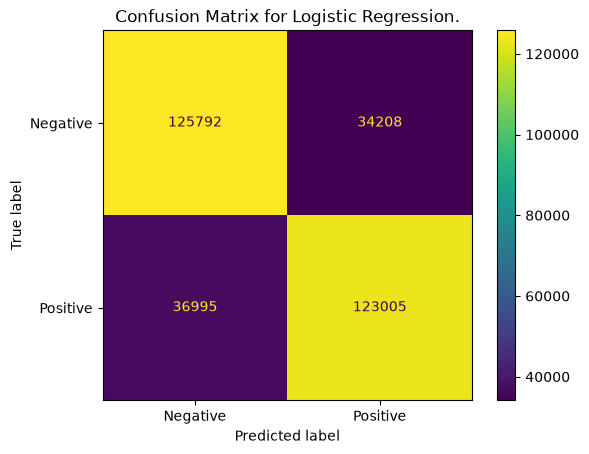

In [125]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot()
plt.title("Confusion Matrix for Logistic Regression.")
plt.show()

Naive bayes model get worse results in this dataset.

In [126]:
model.fit(X_train_tf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[639999.,640000.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 10000)","[[201.87,104.94, 33.63,..., 11.17, 6.75, 9.6 ], [139.89,190.98, 16.01,..., 53.04, 38.15, 60.48]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 10000)","[[ -9.16, -9.81,-10.93,...,-11.97,-12.43,-12.11], [ -9.48, -9.17,-11.59,...,-10.44,-10.76,-10.31]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [127]:
y_pred = model.predict(X_test_tf)

In [128]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Precision: {precision:.2f}")

recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Recall: {recall:.2f}")

error_rate = 1 - accuracy
print(f"Error Rate: {error_rate:.2f}")

f1 = f1_score(y_test, y_pred, average="macro")
print(f"F1: {f1:.2f}")

Accuracy: 0.77
Precision: 0.77
Recall: 0.77
Error Rate: 0.23
F1: 0.77


TfidfVectorizer gives even worse results compared to CountVectorizer with a Naive Bayes model.

In [129]:
model = LinearSVC(random_state=11, tol=1e-5)

model.fit(X_train_vec, y_train)

,"tol tol: float, default=1e-4Tolerance for stopping criteria.",1e-05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",11
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adju

In [130]:
y_pred = model.predict(X_test_vec)

In [131]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Precision: {precision:.2f}")

recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Recall: {recall:.2f}")

error_rate = 1 - accuracy
print(f"Error Rate: {error_rate:.2f}")

f1 = f1_score(y_test, y_pred, average="macro")
print(f"F1: {f1:.2f}")

Accuracy: 0.79
Precision: 0.80
Recall: 0.79
Error Rate: 0.21
F1: 0.79


In [132]:
report = classification_report(y_test, y_pred)
print(f"Classification Report: {report}")

Classification Report:               precision    recall  f1-score   support

           0       0.81      0.77      0.79    160000
           1       0.78      0.82      0.80    160000

    accuracy                           0.79    320000
   macro avg       0.80      0.79      0.79    320000
weighted avg       0.80      0.79      0.79    320000



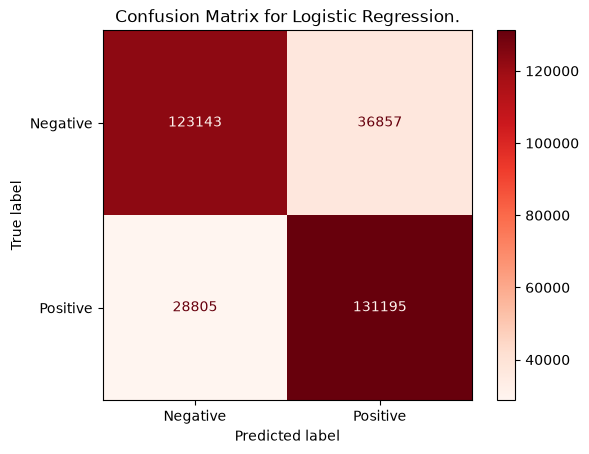

In [133]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Reds")
plt.title("Confusion Matrix for Logistic Regression.")
plt.show()

In [134]:
model.fit(X_train_tf, y_train)

,"tol tol: float, default=1e-4Tolerance for stopping criteria.",1e-05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",11
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adju

In [135]:
y_pred = model.predict(X_test_tf)

In [136]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Precision: {precision:.2f}")

recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Recall: {recall:.2f}")

error_rate = 1 - accuracy
print(f"Error Rate: {error_rate:.2f}")

f1 = f1_score(y_test, y_pred, average="macro")
print(f"F1: {f1:.2f}")

Accuracy: 0.80
Precision: 0.80
Recall: 0.80
Error Rate: 0.20
F1: 0.80


In [137]:
report = classification_report(y_test, y_pred)
print(f"Classification Report: {report}")

Classification Report:               precision    recall  f1-score   support

           0       0.81      0.78      0.79    160000
           1       0.79      0.81      0.80    160000

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



Almost every model gets same result on this dataset.

| Model       | Vectorizer | Accuracy | Precision | Recall | F1 |
| ----------- | ---------- | -------- | --------- | ------ | -- |
| Logistic    | Count      |    80    |     80    |   80   | 80 |
| Logistic    | TF-IDF     |    80    |     80    |   80   | 80 |
| Naive Bayes | Count      |    78    |     78    |   78   | 78 |
| Naive Bayes | TF-IDF     |    77    |     77    |   77   | 77 |
| Linear SVM  | Count      |    79    |     80    |   79   | 79 |
| Linear SVM  | TF-IDF     |    80    |     80    |   80   | 80 |


In [144]:
wrong_idx = y_test != y_pred
wrong_sentences = X_test[wrong_idx]
wrong_true = y_test[wrong_idx]
wrong_pred = y_pred[wrong_idx]

In [147]:
wrong_idx.value_counts()

Label
False    254819
True      65181
Name: count, dtype: int64

In [145]:
for text, true_label, pred_label in zip(wrong_sentences[:10],
                                        wrong_true[:10], wrong_pred[:10]):
    print(f"Text: {text}")
    print(f"True: {true_label}, Pred: {pred_label}")
    print("=" * 50)

Text: back at work loved the bb&amp;n one-acts - lae was fantastic spring awakening
True: 0, Pred: 1
Text: take a spotlight so you can get some good light on them. ;) long way home for you too.
True: 0, Pred: 1
Text: you r so not funny but okie doke see ya in an hour or two
True: 0, Pred: 1
Text: another mountain rescue full day ahead
True: 0, Pred: 1
Text: but you have to remember that they have not even really started post preduction yet.
True: 1, Pred: 0
Text: heading downtown to cathrine and walter's going away party
True: 0, Pred: 1
Text: ah yay no school today, exams this friday
True: 0, Pred: 1
Text: good morning people of twitterland last day in melbourne
True: 0, Pred: 1
Text: thank you firefox for crashing on me, halfway through a complex online form
True: 0, Pred: 1
Text: looks like class it is then. laters, tweets
True: 0, Pred: 1


In [151]:
base_model = LinearSVC(random_state=11, tol=1e-5)

joblib.dump(
    base_model,
    "../models/svm.pk1"
)

['../models/svm.pk1']